In [5]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

play = pd.read_csv("Play Store Data.csv")
reviews = pd.read_csv("User Reviews.csv")

In [6]:
print(play.shape)
print()
print(play.info())

(10841, 13)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB
None


In [7]:
print(reviews.shape)
print()
print(reviews.info())

(64295, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB
None


In [9]:
play = play.drop_duplicates(subset="App")
play = play.reset_index(drop=True)
play.shape

(9660, 13)

In [11]:
play = play[play["Category"] != "1.9"]
play = play.reset_index(drop=True)

In [16]:
play["Reviews"] = pd.to_numeric(
    play["Reviews"],
    errors="coerce"
)
play["Installs"] = (
    play["Installs"]
    .astype(str)
    .str.replace(",", "")
    .str.replace("+", "")
)

play["Installs"] = pd.to_numeric(
    play["Installs"],
    errors="coerce"
)
play["Last Updated"] = pd.to_datetime(
    play["Last Updated"],
    errors="coerce"
)
play.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9659 non-null   object        
 1   Category        9659 non-null   object        
 2   Rating          8196 non-null   float64       
 3   Reviews         9659 non-null   int64         
 4   Size            9659 non-null   object        
 5   Installs        9659 non-null   int64         
 6   Type            9658 non-null   object        
 7   Price           9659 non-null   object        
 8   Content Rating  9659 non-null   object        
 9   Genres          9659 non-null   object        
 10  Last Updated    9659 non-null   datetime64[ns]
 11  Current Ver     9651 non-null   object        
 12  Android Ver     9657 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(9)
memory usage: 981.1+ KB


In [17]:
play.isnull().sum()

App                  0
Category             0
Rating            1463
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [19]:
df = play[
    [
        "App",
        "Category",
        "Reviews",
        "Installs",
        "Last Updated"
    ]
].copy()

In [21]:
df = df[
    df["Reviews"] > 500
]

In [23]:
df = df[
    df["Category"]
    .str.startswith(
        ("B", "C", "E"),
        na=False
    )
]

In [25]:
df = df[
    ~df["App"]
    .str.startswith(
        ("X", "Y", "Z"),
        na=False
    )
]

In [27]:
df = df[
    ~df["App"]
    .str.contains(
        "s",
        case=False,
        na=False
    )
]

In [29]:
df["Category"] = (
    df["Category"]
    .replace(
        {
            "BEAUTY": "सौंदर्य",
            "BUSINESS": "வணிகம்",
            "DATING": "Partnersuche"
        }
    )
)

In [33]:
df["Month"] = (
    df["Last Updated"]
    .dt.to_period("M")
    .astype(str)
)
df["Month"]

107     2018-06
136     2018-07
140     2018-08
141     2017-07
142     2018-08
         ...   
9118    2018-08
9273    2015-08
9297    2018-08
9633    2018-07
9647    2016-06
Name: Month, Length: 198, dtype: object

In [36]:
trend = (
    df.groupby(
        ["Month", "Category"]
    )["Installs"]
    .sum()
    .reset_index()
)
trend.head()

,Month,Category,Installs
0,2014-01,COMMUNICATION,100000
1,2014-03,COMMUNICATION,100000
2,2014-05,வணிகம்,100000
3,2014-07,COMMUNICATION,10000000
4,2014-07,EDUCATION,10000


In [38]:
#Month-over-Month Growth
trend["MoM_Growth"] = (
    trend
    .groupby("Category")
    ["Installs"]
    .pct_change()
)

In [40]:
growth = trend[
    trend["MoM_Growth"] > 0.20
]

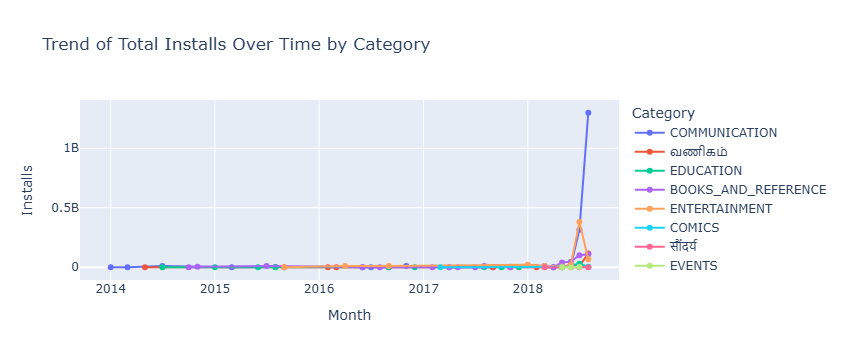

In [43]:
fig = px.line(
    trend,
    x="Month",
    y="Installs",
    color="Category",
    markers=True,
    title="Trend of Total Installs Over Time by Category"
)
fig.show()

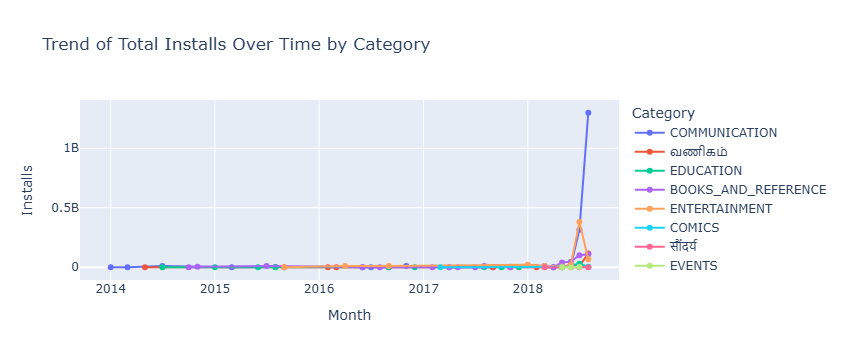

In [46]:
for _, row in growth.iterrows():

    fig.add_vrect(
        x0=row["Month"],
        x1=row["Month"],
        fillcolor="lightgreen",
        opacity=0.3,
        line_width=0
    )
fig.show()

In [48]:
from datetime import datetime
import pytz

india = pytz.timezone(
    "Asia/Kolkata"
)

now = datetime.now(india)

if 18 <= now.hour < 21:
    fig.show()
else:
    print(
        "Line chart is available only between "
        "6 PM IST and 9 PM IST."
    )

Line chart is available only between 6 PM IST and 9 PM IST.


In [50]:
fig.write_html(
    "time_series_dashboard.html",
    include_plotlyjs="cdn"
)